# Test vf2 algorithm

In [102]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

# import qiskit
# print(qiskit.__qiskit_version__)
    
from qiskit.transpiler import CouplingMap
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.tools.visualization import circuit_drawer
from qiskit.converters import dag_to_circuit, circuit_to_dag
from qiskit.dagcircuit import DAGOpNode

import matplotlib.pyplot as plt

from vfs import Vf

import networkx as nx
# from qiskit.tools.parallel import CPU_COUNT
# print('CPU Count: ', CPU_COUNT)

def is_embeddable(g, H, anchor, stop):
    '''check if a small graph g is embeddable in a large H, anchor is bool
        g, H (Graph)
        anchor (bool): whether or not mapping anchor of g to that of H
        stop (float): time limit for vf2
    '''
    vf2 = Vf()
    result = {} 
    if anchor: result[hub(g)] = hub(H)
    result = vf2.dfsMatch(g, H, result, stop)
    lng = len(nx.nodes(g))
    if len(result) == lng:
        return True, result   
    return False, result

def CreateCircuitFromQASM(file, path):
    QASM_file = open(path + file, 'r')
    iter_f = iter(QASM_file)
    QASM = ''
    for line in iter_f: 
        QASM = QASM + line
    #print(QASM)
    cir = QuantumCircuit.from_qasm_str(QASM)
    QASM_file.close    
    return cir

def ReducedCircuit(circ_qasm):
    '''Return Reduced Circuit containing only [name, [p,q]], e.g., ['cx', [0,2]] '''
    C = []
    for gate in circ_qasm:
        if gate[0].name != 'cx': continue
        qubits = [q._index for q in gate[1]]
        if C and set(qubits) == set(C[-1]): continue 
        C.append(qubits)
    # self.circuit = C[:]
    return C

def extract_circuit(filename, path, node_num):
    # compose the input Quantum Circuit
    q = QuantumRegister(node_num, 'q')
    cir_in = QuantumCircuit(q)
    cir_temp = cir_in.from_qasm_file(path+filename)
    cir_in.compose(cir_temp, inplace=True)
    if node_num < cir_temp.num_qubits:
        raise Exception("Cannot compose circuit!") 

    return cir_in

def graph_of_circuit(circuit):
    ''' Return the induced graph of the reduced circuit C
            - node set: qubits in C
            - edge set: all pair (p,q) if CNOT [p,q] or CNOT[q,p] in C
        Args:
            C (list): the input reduced circuit
        Returns:
            g (Graph)
    '''   
    g = nx.Graph()
    for gate in circuit:
        if gate.operation.name != 'cx': continue
        p, q = gate.qubits[0]._index, gate.qubits[1]._index
        g.add_edge(p,q)
    return g  

def graph_of_redcirc(redcirc):
    ''' Return the induced graph of the reduced circuit C
            - node set: qubits in C
            - edge set: all pair (p,q) if CNOT [p,q] or CNOT[q,p] in C
        Args:
            C (list): the input reduced circuit
        Returns:
            g (Graph)
    '''   
    g = nx.Graph()
    for gate in redcirc:
        p, q = gate
        g.add_edge(p,q)
    return g  

Wed Sep 13 19:13:21 2023
instructions of the circuit
3 4 5
5 4 5
7 4 3
9 3 5
11 3 5
13 4 3
15 3 5
17 3 5
19 3 2
21 2 5
23 2 5
25 4 2
27 2 5
29 2 5
31 3 2
33 2 5
35 2 5
37 4 2
39 2 5
41 2 5
43 2 1
45 1 5
47 1 5
49 4 1
51 1 5
53 1 5
55 3 1
57 1 5
59 1 5
61 4 1
63 1 5
65 1 5
67 2 1
69 1 5
71 1 5
73 4 1
75 1 5
77 1 5
79 3 1
81 1 5
83 1 5
85 4 1
87 1 5
89 1 5
91 1 0
93 0 5
95 0 5
97 4 0
99 0 5
101 0 5
103 3 0
105 0 5
107 0 5
109 4 0
111 0 5
113 0 5
115 2 0
117 0 5
119 0 5
121 4 0
123 0 5
125 0 5
127 3 0
129 0 5
131 0 5
133 4 0
135 0 5
137 0 5
139 1 0
141 0 5
143 0 5
145 4 0
147 0 5
149 0 5
151 3 0
153 0 5
155 0 5
157 4 0
159 0 5
161 0 5
163 2 0
165 0 5
167 0 5
169 4 0
171 0 5
173 0 5
175 3 0
177 0 5
179 0 5
181 4 0
183 0 5
185 0 5
[[4, 5], [4, 3], [3, 5], [4, 3], [3, 5], [3, 2], [2, 5], [4, 2], [2, 5], [3, 2], [2, 5], [4, 2], [2, 5], [2, 1], [1, 5], [4, 1], [1, 5], [3, 1], [1, 5], [4, 1], [1, 5], [2, 1], [1, 5], [4, 1], [1, 5], [3, 1], [1, 5], [4, 1], [1, 5], [1, 0], [0, 5], [4, 0], [0, 5],

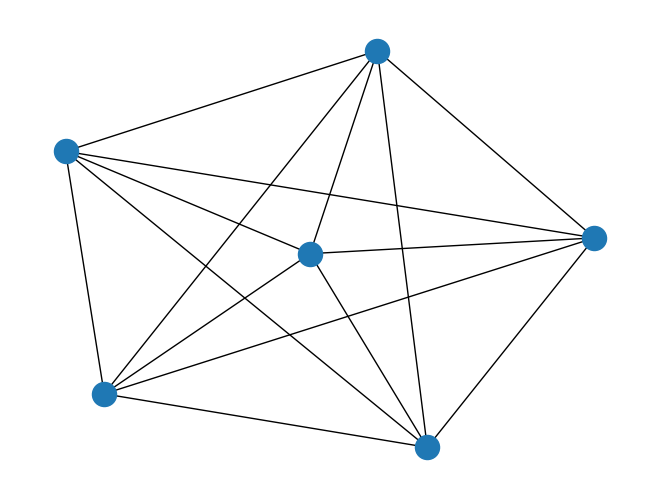

(False, {})
Used time (s): 0.18 Wed Sep 13 19:13:22 2023


In [103]:
import ag
import time
import os
"""AG and Benchmarks"""

AG = ag.qgrid(2,3)
#AG_name = 'G2x3'
#path = '../bench/6Qbench/'
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'AND_6.qasm' 
#AG = ag.q20() 

import matplotlib.pyplot as plt


coupling_map = CouplingMap(couplinglist=AG.edges())

start = time.time()    
print(time.asctime())

'''Extract the circuit from qasm files'''
circuit = extract_circuit(filename, path, coupling_map.size())
#print(circuit.depth(), circuit.count_ops(), circuit.size())
#print(circuit.data[-1])
newcirc = ReducedCircuit(circuit)

dagcircuit = circuit_to_dag(circuit)

for node in dagcircuit.nodes():
    if not isinstance(node, DAGOpNode): 
        #print('ha')
        continue
    #print(type(node), node.op.name)

print('instructions of the circuit')
i = 0
for instruction in circuit:
    i += 1
    if len(instruction.qubits) != 2: continue
    #if instruction.operation.name == 'cx': continue
    #break
    
    print(i, instruction.qubits[0]._index,instruction.qubits[1]._index)
    
    
print(newcirc)
#circuit.draw('mpl')
print(f'the circuit has {len(circuit)} gates')
granule = 200
for i in range(len(circuit)//granule+1):
    #print(f'subcircuit {i}')
    g = graph_of_circuit(circuit[i*granule:(i+1)*granule])
    nx.draw(g, font_size=8)
    plt.show()
    print(is_embeddable(g,AG,False,10))

end = time.time()
print('Used time (s):', round(end-start,2), time.asctime() )
